In [17]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import resample
from agents.ffnn_agent2 import FFNNAgent
from torch.utils.data import TensorDataset, DataLoader
import torch
import matplotlib.pyplot as plt
import random
import os
import json
from itertools import cycle
from typing import List, Dict

In [18]:
import re
from pathlib import Path

# ---------- Helpers ----------

def is_seed_dir(p: Path) -> bool:
    return (
        p.is_dir()
        and p.name.startswith("seed_")
        and (p / "metrics.csv").is_file()
        and (p / "meta.json").is_file()
    )

def is_experiment_dir(p: Path) -> bool:
    if not p.is_dir():
        return False
    return any(is_seed_dir(d) for d in p.iterdir())

# Regex to extract PCA, minID, majID, BIAS
CORE_RE = re.compile(
    r"PCA(?P<pca>\d+).*?minID(?P<min>\d+).*?majID(?P<maj>\d+).*?BIAS(?P<bias>[0-9.]+)",
    re.IGNORECASE,
)

def make_short_label(exp_name: str) -> str:
    """
    Extract PCA, minID, majID, bias from a folder name.
    Return a short readable label like:
        PCA4_min1_maj0_bias0.35
    """
    m = CORE_RE.search(exp_name)
    if not m:
        # fallback: return the core part without DATE
        core = exp_name.split("_DATE")[0]
        return core

    pca = m.group("pca")
    min_id = m.group("min")
    maj_id = m.group("maj")
    bias = m.group("bias")

    return f"PCA{pca}_min{min_id}_maj{maj_id}_bias{bias}"

# ---------- Main Generator ----------

def generate_experiment_labels_dict():
    training_root = Path("training_runs")
    if not training_root.is_dir():
        print("[error] training_runs/ does not exist.")
        return

    exp_dirs = sorted(
        [d for d in training_root.iterdir() if is_experiment_dir(d)],
        key=lambda p: p.name,
    )

    if not exp_dirs:
        print("[info] No experiment folders found.")
        return

    print("\n# ================= GENERATED EXPERIMENT_LABELS =================")
    print("EXPERIMENT_LABELS = {")
    for d in exp_dirs:
        short = make_short_label(d.name)
        print(f'    "{d.name}": "{short}",')
    print("}")
    print("# ==============================================================\n")

# Run immediately
generate_experiment_labels_dict()



# ================= GENERATED EXPERIMENT_LABELS =================
EXPERIMENT_LABELS = {
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ10000_REAL3000_BIAS0.35_G202512291930_005b211d": "PCA10_min13_maj12_bias0.35",
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ1000_REAL1500_BIAS0.35_G202512291930_b33abece": "PCA10_min13_maj12_bias0.35",
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512291930_0a4a5707": "PCA10_min13_maj12_bias0.35",
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512291930_6d7b645b": "PCA10_min13_maj12_bias0.35",
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512291930_dd5d91c8": "PCA10_min13_maj12_bias0.35",
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ3000_REAL2000_BIAS0.35_G202512291930_73c92301": "PCA10_min13_maj12_bias0.35",
    "EP6000_PCA10_REWlocal_gauss_minID2_majID3_TRJ2000_REAL3000_BIAS0.35_G202512291930_8f109bb2": "PCA10_min2_maj3_bias0.35",
    

[info] Using 9 experiment folders from EXPERIMENT_LABELS.


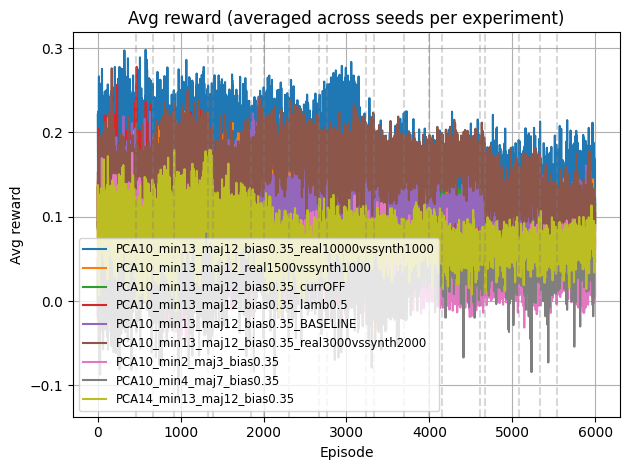

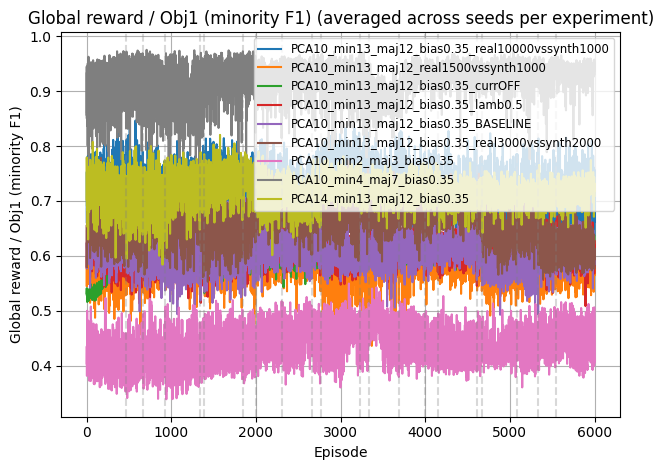

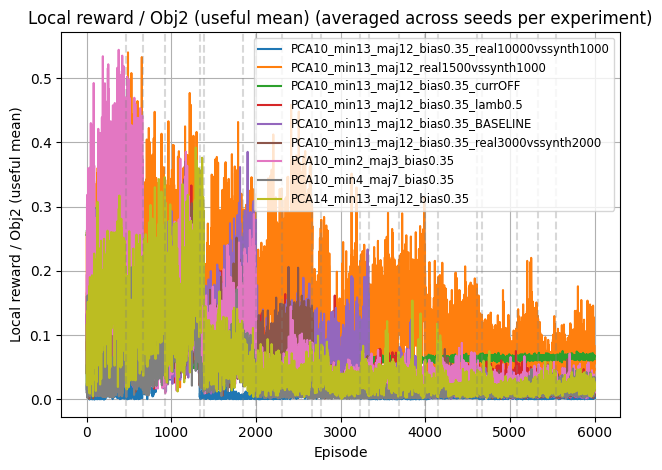

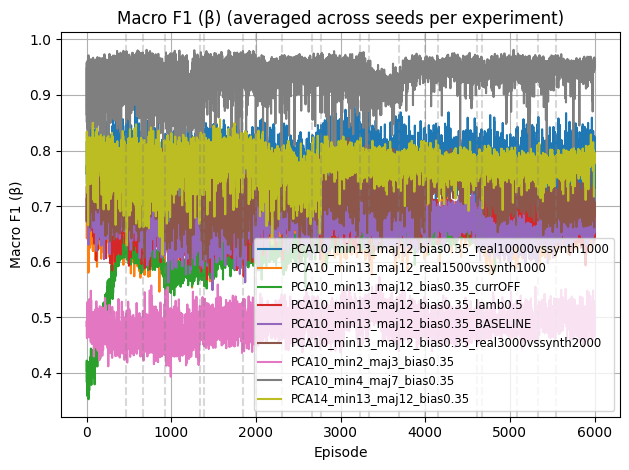

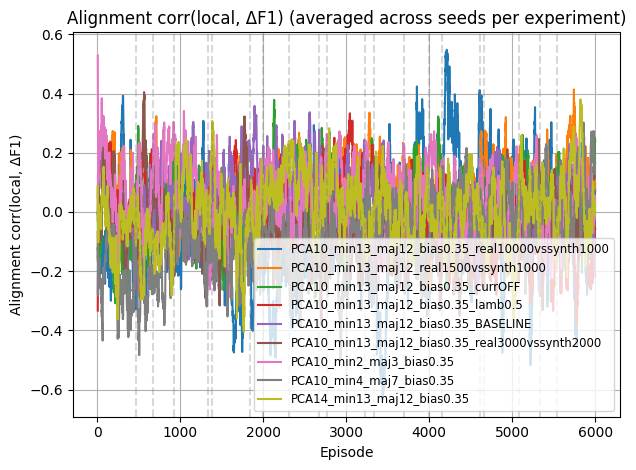

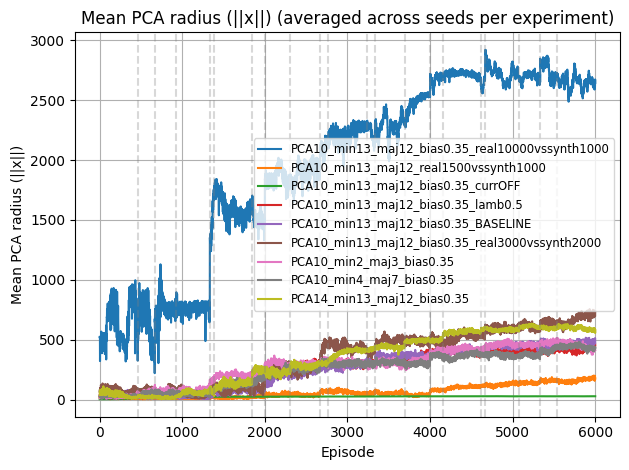

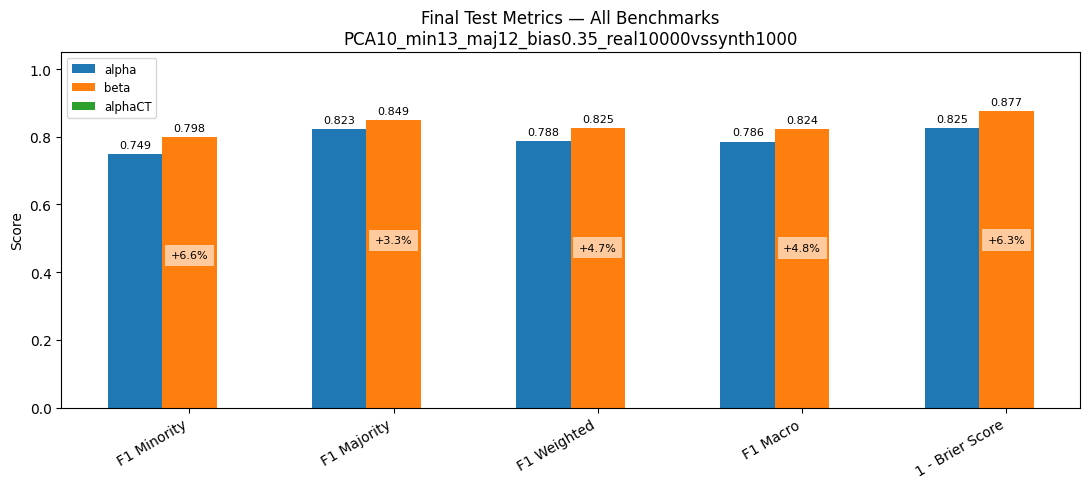

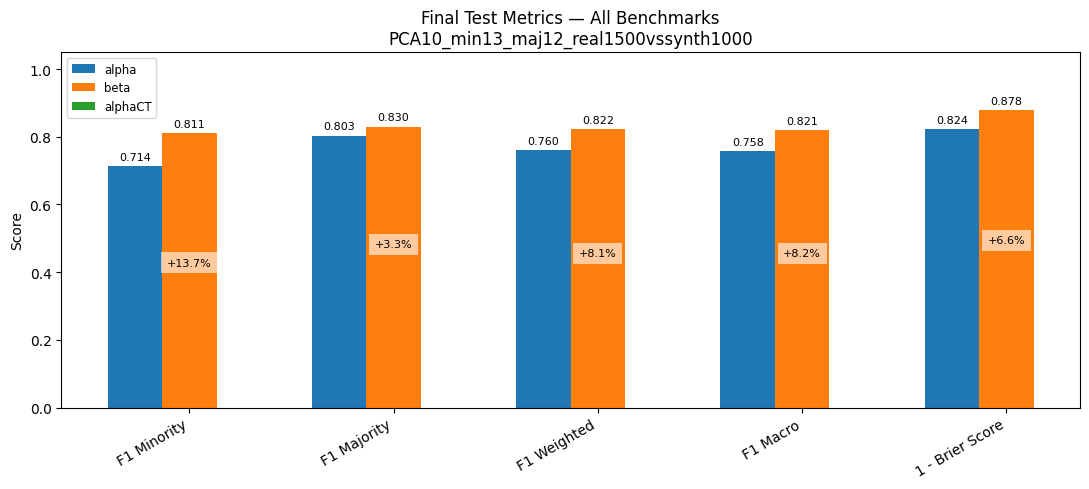

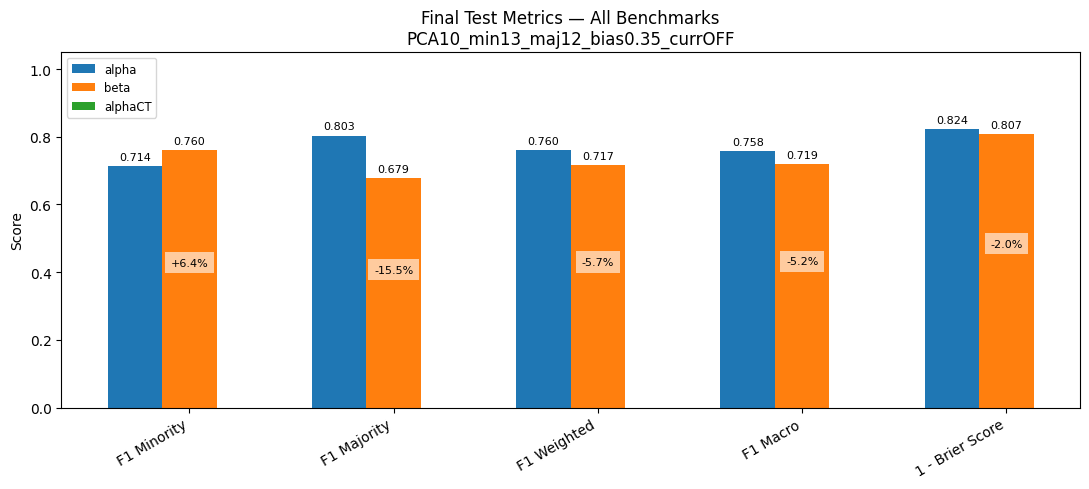

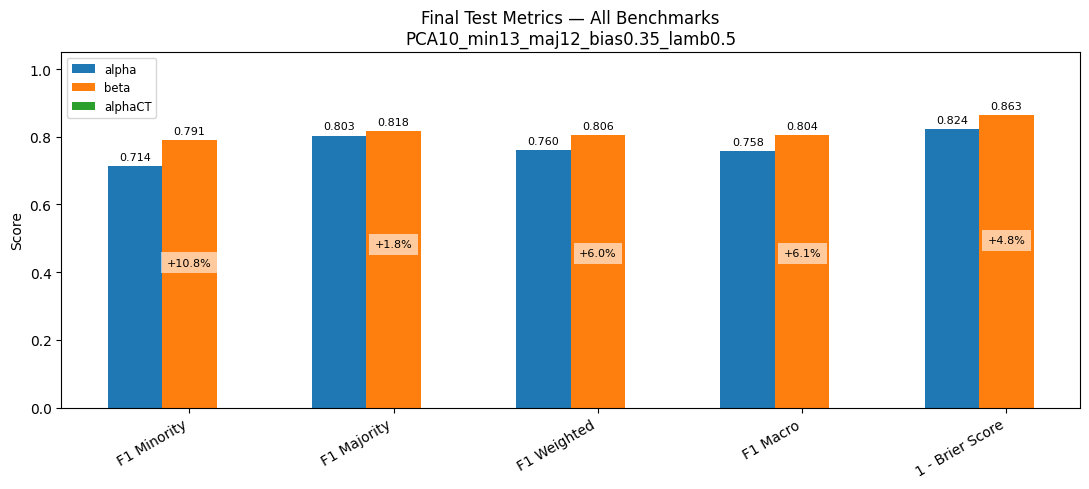

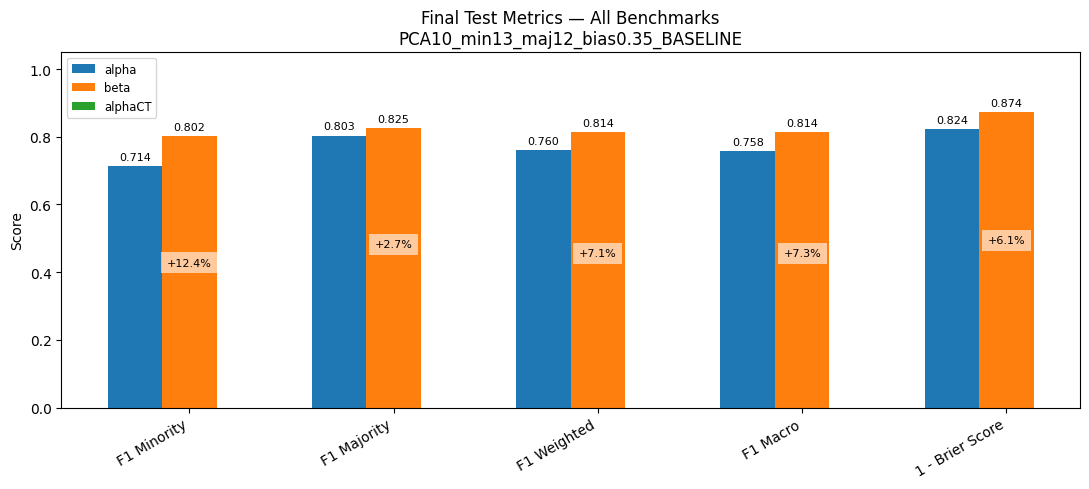

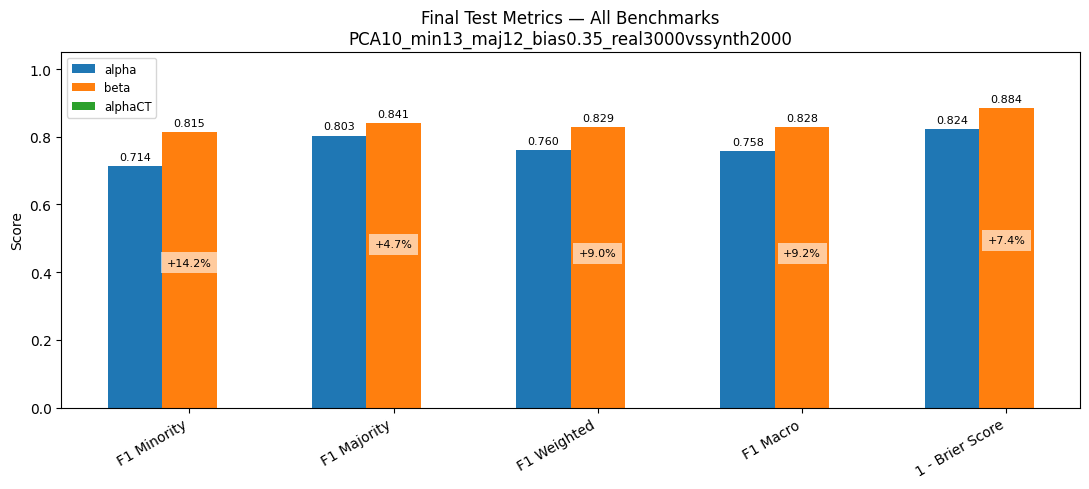

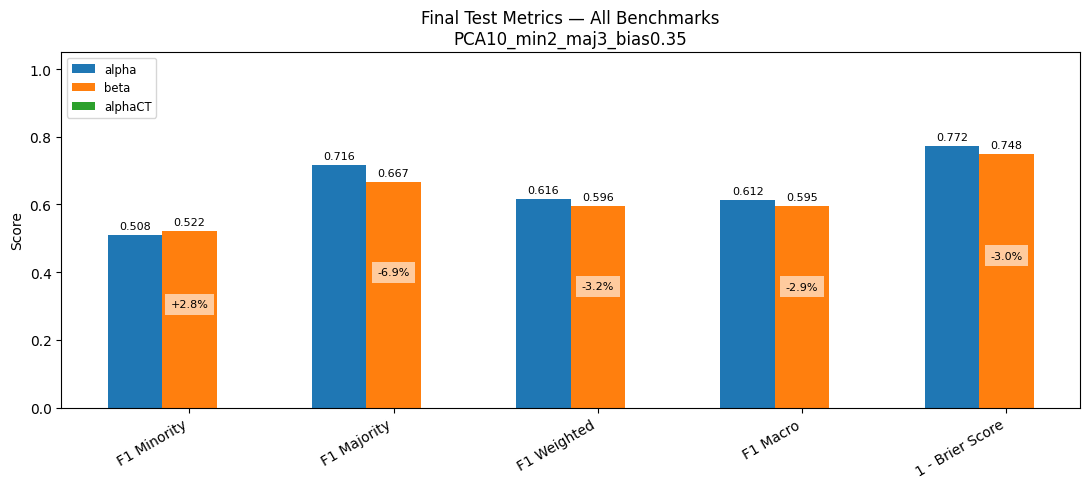

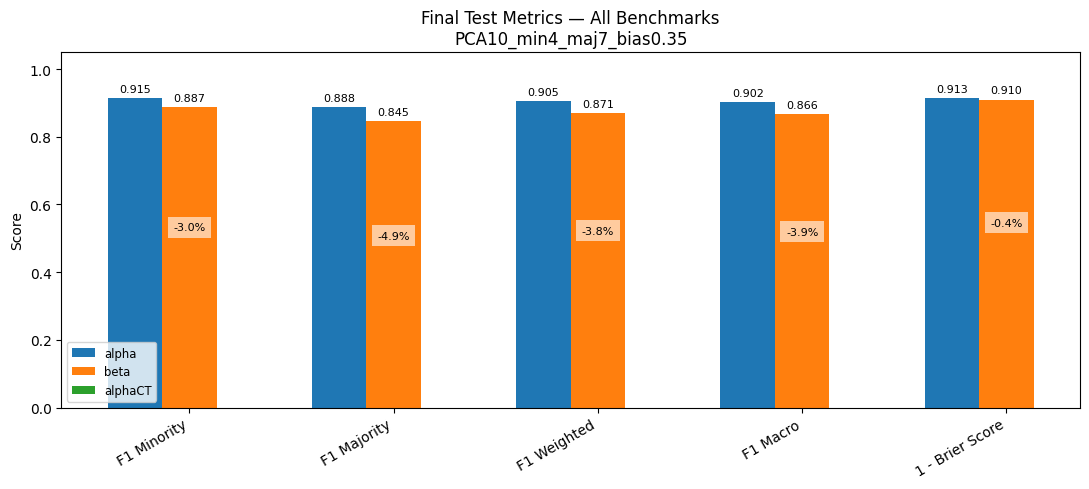

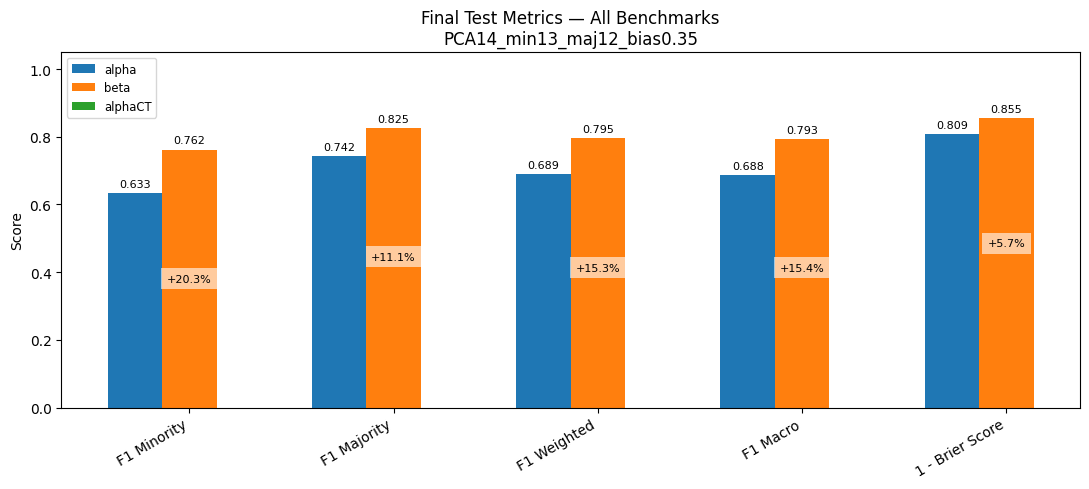

In [23]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("training_runs")

# ============================================================
# 1) SELECT WHICH EXPERIMENTS TO PLOT
# ============================================================
EXPERIMENT_LABELS = {
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ10000_REAL3000_BIAS0.35_G202512291930_005b211d": "PCA10_min13_maj12_bias0.35_real10000vssynth1000",
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ1000_REAL1500_BIAS0.35_G202512291930_b33abece": "PCA10_min13_maj12_real1500vssynth1000",
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512291930_0a4a5707": "PCA10_min13_maj12_bias0.35_currOFF",#curr off
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512291930_6d7b645b": "PCA10_min13_maj12_bias0.35_lamb0.5",
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512291930_dd5d91c8": "PCA10_min13_maj12_bias0.35_BASELINE",
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ3000_REAL2000_BIAS0.35_G202512291930_73c92301": "PCA10_min13_maj12_bias0.35_real3000vssynth2000",
    "EP6000_PCA10_REWlocal_gauss_minID2_majID3_TRJ2000_REAL3000_BIAS0.35_G202512291930_8f109bb2": "PCA10_min2_maj3_bias0.35",#2 vs 3
    "EP6000_PCA10_REWlocal_gauss_minID4_majID7_TRJ2000_REAL3000_BIAS0.35_G202512291930_5e7abc6a": "PCA10_min4_maj7_bias0.35",#4 vs 7
    "EP6000_PCA14_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512291930_df7caea7": "PCA14_min13_maj12_bias0.35",

}


# Metrics to actually plot (time-series)
METRIC_COLS = {
    "reward.avg_reward": "Avg reward",
    "reward.obj1_f1_minority_beta": "Global reward / Obj1 (minority F1)",
    "reward.obj2_local_useful_mean": "Local reward / Obj2 (useful mean)",
    "reward.macro_f1_beta": "Macro F1 (β)",
    # 🔹 alignment curve
    "align.corr_local_delta": "Alignment corr(local, ΔF1)",
    # 🔹 PCA radius of generated points
    "newr.diag_gen_radius_mean": "Mean PCA radius (||x||)",
    # (optional) mean confidence on generated points
    # "newr.diag_mean_conf_all": "Mean confidence α on gen",
}

# Column name for curriculum stage
STAGE_COL = "align.curriculum_stage"

# ---------------------------------------------------------------------
# Helpers to identify experiment + seed folders
# ---------------------------------------------------------------------
def is_seed_dir(p: Path) -> bool:
    return (
        p.is_dir()
        and p.name.startswith("seed_")
        and (p / "metrics.csv").is_file()
        and (p / "meta.json").is_file()
    )

def is_experiment_dir(p: Path) -> bool:
    if not p.is_dir():
        return False
    seeds = [d for d in p.iterdir() if is_seed_dir(d)]
    return len(seeds) > 0

# ---------------------------------------------------------------------
# Parse experiment name (for auto labels if needed)
# ---------------------------------------------------------------------
CORE_RE = re.compile(
    r"^EP(?P<episodes>\d+)_"
    r"PCA(?P<pca>\d+)_"
    r"REW(?P<rew>.+?)_"
    r"minID(?P<min>\d+)_"
    r"majID(?P<maj>\d+)_"
    r"TRJ(?P<trj>\d+)_"
    r"REAL(?P<real>\d+)_"
    r"BIAS(?P<bias>[0-9.]+)"
)

def split_core_and_tail(name: str):
    if "_DATE" in name:
        core, tail = name.split("_DATE", 1)
        return core, tail
    return name, ""

def parse_experiment_name(name: str):
    core, _ = split_core_and_tail(name)
    m = CORE_RE.match(core)
    if not m:
        return {"core": core}
    d = m.groupdict()
    d["core"] = core
    for k in ("episodes", "pca", "min", "maj", "trj", "real"):
        d[k] = int(d[k])
    d["bias"] = float(d["bias"])
    return d

def make_auto_label(info: dict) -> str:
    if not info:
        return "unknown"
    return (
        f"PCA{info.get('pca', '?')}_"
        f"min{info.get('min', '?')}_"
        f"maj{info.get('maj', '?')}_"
        f"bias{info.get('bias', '?')}"
    )

def label_for_folder(folder_name: str, info: dict) -> str:
    if folder_name in EXPERIMENT_LABELS:
        return EXPERIMENT_LABELS[folder_name]
    return make_auto_label(info)

# ---------------------------------------------------------------------
# Training metrics (metrics.csv)
# ---------------------------------------------------------------------
def load_seed_metrics(seed_dir: Path) -> pd.DataFrame | None:
    df = pd.read_csv(seed_dir / "metrics.csv")

    # Always try to keep episode + stage column if present
    wanted = ["episode", STAGE_COL] + list(METRIC_COLS.keys())
    cols = [c for c in wanted if c in df.columns]

    if len(cols) <= 1:  # only episode but nothing else
        print(f"[warn] No requested metrics found in {seed_dir / 'metrics.csv'}, skipping this seed.")
        return None

    return df[cols].copy()

def average_experiment_metrics(exp_dir: Path) -> pd.DataFrame | None:
    seed_dirs = [d for d in exp_dir.iterdir() if is_seed_dir(d)]
    if not seed_dirs:
        print(f"[info] No seeds found in {exp_dir}, skipping training curves.")
        return None

    dfs = []
    for sd in seed_dirs:
        df = load_seed_metrics(sd)
        if df is not None:
            df["seed"] = sd.name
            dfs.append(df)

    if not dfs:
        print(f"[info] All seeds in {exp_dir} missing requested metrics, skipping training curves.")
        return None

    all_df = pd.concat(dfs, ignore_index=True)

    # We average over all numeric columns except 'seed'
    numeric_cols = [c for c in all_df.columns if c not in ("seed",)]
    grouped = (
        all_df.groupby("episode", as_index=False)[numeric_cols]
        .mean()
        .sort_values("episode")
    )
    return grouped

# ---------------------------------------------------------------------
# Final test metrics (unchanged)
# ---------------------------------------------------------------------
def aggregate_final_metrics_for_experiment(exp_dir: Path) -> pd.Series | None:
    path = exp_dir / "final_test_metrics.csv"
    if not path.is_file():
        print(f"[info] No final_test_metrics.csv found in {exp_dir.name}, skipping alpha/beta bar plot.")
        return None

    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"[warn] Could not read {path}: {e}")
        return None

    if df.empty:
        print(f"[info] final_test_metrics.csv is empty for {exp_dir.name}.")
        return None

    mean_series = df.mean(numeric_only=True)
    return mean_series

def plot_alpha_vs_beta_bar(exp_dir: Path, exp_label: str, mean_series: pd.Series):
    """
    Dynamically plots all benchmarks present in final_test_metrics.csv.

    Expected column naming:
      <prefix>_f1_minority
      <prefix>_f1_majority
      <prefix>_f1_weighted
      <prefix>_f1_macro
      <prefix>_brier

    Examples of <prefix>:
      alpha, beta, alphaCTAB, alphaCTGAN, alphaJITTER, etc.
    """

    categories = [
        ("f1_minority", "F1 Minority"),
        ("f1_majority", "F1 Majority"),
        ("f1_weighted", "F1 Weighted"),
        ("f1_macro",    "F1 Macro"),
        ("brier",       "1 - Brier Score"),
    ]

    # ---- Discover which prefixes exist (alpha, beta, alphaCTAB, ...) ----
    prefixes = set()
    for col in mean_series.index:
        if not isinstance(col, str):
            continue
        m = re.match(r"^(?P<prefix>.+?)_(f1_minority|f1_majority|f1_weighted|f1_macro|brier)$", col)
        if m:
            prefixes.add(m.group("prefix"))

    if not prefixes:
        print(f"[info] No benchmark metric prefixes found for {exp_dir.name}, skipping bar plot.")
        return

    # Preferred ordering if present
    preferred = ["alpha", "beta", "alphaCTAB", "alphaCTGAN", "alphaCT"]
    ordered = [p for p in preferred if p in prefixes] + sorted([p for p in prefixes if p not in preferred])

    # ---- Build values matrix: shape (num_prefixes, num_categories) ----
    vals = []
    for p in ordered:
        row = []
        for suffix, _label in categories:
            key = f"{p}_{suffix}"
            v = mean_series.get(key, np.nan)

            # Convert brier -> 1-brier so higher=better
            if suffix == "brier" and not np.isnan(v):
                v = 1.0 - float(v)

            row.append(float(v) if v is not None else np.nan)
        vals.append(row)

    vals = np.array(vals, dtype=float)

    # If absolutely everything is NaN, skip
    if np.all(np.isnan(vals)):
        print(f"[info] No usable benchmark metrics for {exp_dir.name}, skipping bar plot.")
        return

    # ---- Plot grouped bars ----
    x = np.arange(len(categories))
    n = len(ordered)

    # Keep bars reasonable width as #benchmarks grows
    group_width = 0.80
    bar_w = group_width / max(n, 1)
    offsets = (np.arange(n) - (n - 1) / 2.0) * bar_w

    fig, ax = plt.subplots(figsize=(11, 5))

    bars = []
    for i, p in enumerate(ordered):
        b = ax.bar(x + offsets[i], vals[i], bar_w, label=p)
        bars.append(b)

        # value annotations
        for rect in b:
            h = rect.get_height()
            if not np.isnan(h):
                ax.annotate(
                    f"{h:.3f}",
                    xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

    # ---- Optional: % improvement annotations vs alpha (if alpha exists) ----
    if "alpha" in ordered:
        alpha_idx = ordered.index("alpha")
        alpha_vals = vals[alpha_idx]

        for i, p in enumerate(ordered):
            if p == "alpha":
                continue
            for j in range(len(categories)):
                a = alpha_vals[j]
                b = vals[i, j]
                if np.isnan(a) or np.isnan(b) or a == 0:
                    continue
                pct = (b - a) / a * 100.0
                ax.text(
                    x[j] + offsets[i],
                    max(0.02, min(a, b) * 0.6),
                    f"{pct:+.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
                )

    ax.set_ylabel("Score")
    ax.set_title(f"Final Test Metrics — All Benchmarks\n{exp_label}")
    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _suf, lbl in categories], rotation=30, ha="right")
    ax.set_ylim(0.0, 1.05)
    ax.legend(fontsize="small")
    plt.tight_layout()


# ---------------------------------------------------------------------
# Main plotting logic
# ---------------------------------------------------------------------
def main():
    if not ROOT.is_dir():
        print(f"[error] {ROOT} does not exist. Run this from the project root.")
        return

    # --- Decide which experiment folders to use ---
    if EXPERIMENT_LABELS:
        exp_dirs = []
        for folder_name in EXPERIMENT_LABELS.keys():
            p = ROOT / folder_name
            if not is_experiment_dir(p):
                print(f"[warn] {p} is not a valid experiment folder (missing seeds/metrics). Skipping.")
                continue
            exp_dirs.append(p)
        exp_dirs = sorted(exp_dirs, key=lambda p: p.name)
        print(f"[info] Using {len(exp_dirs)} experiment folders from EXPERIMENT_LABELS.")
    else:
        exp_dirs = [d for d in ROOT.iterdir() if is_experiment_dir(d)]
        exp_dirs = sorted(exp_dirs, key=lambda p: p.name)
        print(f"[info] Auto-discovered {len(exp_dirs)} experiment folders under {ROOT}.")

    if not exp_dirs:
        print("[info] No experiment folders selected/found. Nothing to plot.")
        return

    avg_cache: dict[str, pd.DataFrame] = {}
    info_cache: dict[str, dict] = {}
    final_cache: dict[str, pd.Series] = {}

    for exp_dir in exp_dirs:
        name = exp_dir.name
        info_cache[name] = parse_experiment_name(name)

        avg_df = average_experiment_metrics(exp_dir)
        if avg_df is not None:
            avg_cache[name] = avg_df

        final_series = aggregate_final_metrics_for_experiment(exp_dir)
        if final_series is not None:
            final_cache[name] = final_series

    # Precompute curriculum stage change positions (episodes)
    stage_transitions = set()
    for name, df in avg_cache.items():
        if STAGE_COL in df.columns:
            stages = df[STAGE_COL].values
            episodes = df["episode"].values
            for i in range(1, len(stages)):
                if stages[i] != stages[i-1]:
                    stage_transitions.add(float(episodes[i]))
    stage_transitions = sorted(stage_transitions)

    # ============================================================
    # 1) Time-series plots
    # ============================================================
    for metric_col, metric_label in METRIC_COLS.items():
        plt.figure()
        plotted_any = False

        for exp_dir in exp_dirs:
            name = exp_dir.name
            if name not in avg_cache:
                continue
            avg_df = avg_cache[name]
            if metric_col not in avg_df.columns:
                continue

            info = info_cache.get(name, {})
            label = label_for_folder(name, info)
            plt.plot(avg_df["episode"], avg_df[metric_col], label=label)
            plotted_any = True

        if not plotted_any:
            print(f"[info] No data for metric {metric_col}; skipping TS plot.")
            plt.close()
            continue

        # draw curriculum stage transitions
        for ep in stage_transitions:
            plt.axvline(ep, linestyle="--", color="gray", alpha=0.3)

        plt.xlabel("Episode")
        plt.ylabel(metric_label)
        plt.title(f"{metric_label} (averaged across seeds per experiment)")
        plt.grid(True)
        plt.legend(fontsize="small")
        plt.tight_layout()

    # ============================================================
    # 2) Final Alpha vs Beta bar plots
    # ============================================================
    for exp_dir in exp_dirs:
        name = exp_dir.name
        if name not in final_cache:
            continue
        mean_series = final_cache[name]
        info = info_cache.get(name, {})
        exp_label = label_for_folder(name, info)
        plot_alpha_vs_beta_bar(exp_dir, exp_label, mean_series)

    plt.show()

if __name__ == "__main__":
    main()


In [24]:
#1312
# | Metric                  | Average       |
# | ----------------------- | ------------- |
# | **alphaCT_f1_minority** | **0.7855041** |
# | **alphaCT_f1_majority** | **0.6153448** |
# | **alphaCT_f1_weighted** | **0.6952365** |
# | **alphaCT_f1_macro**    | **0.7004245** |
# | **alphaCT_brier**       | **0.1979598** |

# #134
# | Metric                  | Average       |
# | ----------------------- | ------------- |
# | **alphaCT_f1_minority** | **0.9015152** |
# | **alphaCT_f1_majority** | **0.9417683** |
# | **alphaCT_f1_weighted** | **0.9283892** |
# | **alphaCT_f1_macro**    | **0.9216417** |
# | **alphaCT_brier**       | **0.0575585** |

#10
# | Metric                  | Average       |
# | ----------------------- | ------------- |
# | **alphaCT_f1_minority** | **0.6445781** |
# | **alphaCT_f1_majority** | **0.8482108** |
# | **alphaCT_f1_weighted** | **0.7991551** |
# | **alphaCT_f1_macro**    | **0.7463944** |
# | **alphaCT_brier**       | **0.1438272** |



In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

ROOT = Path("training_runs")

# ============================================================
# 1) SELECT WHICH EXPERIMENTS TO PLOT
# ============================================================
EXPERIMENT_LABELS = {
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512151601_75165367": "PCA10_min13_maj12_bias0.35",
    "EP6000_PCA10_REWlocal_gauss_minID13_majID4_TRJ2000_REAL3000_BIAS0.35_G202512151601_d941e1bb": "PCA10_min13_maj4_bias0.35",
    "EP6000_PCA10_REWlocal_gauss_minID1_majID0_TRJ2000_REAL3000_BIAS0.35_G202512151601_01804334": "PCA10_min1_maj0_bias0.35",
}

# ============================================================
# 2) MANUAL CTGAN BASELINES (keyed by (minID, majID))
#    Values are your alphaCT_* averages
# ============================================================
CTGAN_BASELINES = {
    (13, 12): {
        "f1_minority": 0.7855041,
        "f1_majority": 0.6153448,
        "f1_weighted": 0.6952365,
        "f1_macro":    0.7004245,
        "brier":       0.1979598,
    },
    (13, 4): {
        "f1_minority": 0.9015152,
        "f1_majority": 0.9417683,
        "f1_weighted": 0.9283892,
        "f1_macro":    0.9216417,
        "brier":       0.0575585,
    },
    (1, 0): {
        "f1_minority": 0.6445781,
        "f1_majority": 0.8482108,
        "f1_weighted": 0.7991551,
        "f1_macro":    0.7463944,
        "brier":       0.1438272,
    },
}

# ============================================================
# Parse minID / majID from experiment folder name
# ============================================================
MINMAJ_RE = re.compile(r"minID(?P<min>\d+)_majID(?P<maj>\d+)")

def parse_min_maj(exp_name: str) -> tuple[int | None, int | None]:
    m = MINMAJ_RE.search(exp_name)
    if not m:
        return None, None
    return int(m.group("min")), int(m.group("maj"))

# ============================================================
# Load final metrics
# ============================================================
def aggregate_final_metrics_for_experiment(exp_dir: Path) -> pd.Series | None:
    path = exp_dir / "final_test_metrics.csv"
    if not path.is_file():
        print(f"[info] No final_test_metrics.csv found in {exp_dir.name}, skipping.")
        return None
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"[warn] Could not read {path}: {e}")
        return None
    if df.empty:
        print(f"[info] final_test_metrics.csv is empty for {exp_dir.name}.")
        return None
    return df.mean(numeric_only=True)

# ============================================================
# Plot: Alpha vs Beta vs CTGAN (CTGAN optional per exp)
# ============================================================
def plot_alpha_beta_ctgan(exp_label: str, mean_series: pd.Series, ctgan: dict | None):
    categories = ["F1 Minority", "F1 Majority", "F1 Weighted", "F1 Macro", "1 - Brier Score"]
    x = np.arange(len(categories))

    alpha_vals = np.array([
        mean_series.get("alpha_f1_minority", np.nan),
        mean_series.get("alpha_f1_majority", np.nan),
        mean_series.get("alpha_f1_weighted", np.nan),
        mean_series.get("alpha_f1_macro", np.nan),
        (1.0 - mean_series.get("alpha_brier", np.nan)) if "alpha_brier" in mean_series else np.nan,
    ], dtype=float)

    beta_vals = np.array([
        mean_series.get("beta_f1_minority", np.nan),
        mean_series.get("beta_f1_majority", np.nan),
        mean_series.get("beta_f1_weighted", np.nan),
        mean_series.get("beta_f1_macro", np.nan),
        (1.0 - mean_series.get("beta_brier", np.nan)) if "beta_brier" in mean_series else np.nan,
    ], dtype=float)

    if ctgan is None:
        ctgan_vals = np.array([np.nan]*len(categories), dtype=float)
    else:
        ctgan_vals = np.array([
            ctgan.get("f1_minority", np.nan),
            ctgan.get("f1_majority", np.nan),
            ctgan.get("f1_weighted", np.nan),
            ctgan.get("f1_macro", np.nan),
            (1.0 - ctgan.get("brier", np.nan)),
        ], dtype=float)

    if np.all(np.isnan(alpha_vals)) and np.all(np.isnan(beta_vals)) and np.all(np.isnan(ctgan_vals)):
        print(f"[info] No usable metrics for {exp_label}, skipping.")
        return

    width = 0.25
    fig, ax = plt.subplots(figsize=(11, 5))

    r1 = ax.bar(x - width, alpha_vals, width, label="Alpha", color="red")
    r2 = ax.bar(x,         beta_vals,  width, label="Beta",  color="green")
    r3 = ax.bar(x + width, ctgan_vals, width, label="CTGAN", color="blue")

    def annotate(rects):
        for r in rects:
            h = r.get_height()
            if not np.isnan(h):
                ax.annotate(
                    f"{h:.3f}",
                    xy=(r.get_x() + r.get_width()/2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

    annotate(r1); annotate(r2); annotate(r3)

    # Optional: show % change vs CTGAN (Beta relative to CTGAN) as overlay text
    for i in range(len(categories)):
        c = ctgan_vals[i]
        b = beta_vals[i]
        if np.isnan(c) or np.isnan(b) or c == 0:
            continue
        pct = (b - c) / c * 100.0
        ax.text(
            x[i],
            0.05,  # near bottom
            f"Beta vs CTGAN: {pct:+.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )

    ax.set_ylabel("Score")
    ax.set_title(f"Final Test Metrics — Alpha vs Beta vs CTGAN\n{exp_label}")
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=30, ha="right")
    ax.set_ylim(0.0, 1.05)
    ax.legend()
    plt.tight_layout()

def main():
    if not ROOT.is_dir():
        print(f"[error] {ROOT} does not exist. Run this from the project root.")
        return

    for folder_name, exp_label in EXPERIMENT_LABELS.items():
        exp_dir = ROOT / folder_name
        mean_series = aggregate_final_metrics_for_experiment(exp_dir)
        if mean_series is None:
            continue

        min_id, maj_id = parse_min_maj(folder_name)
        ctgan = None
        if min_id is not None and maj_id is not None:
            ctgan = CTGAN_BASELINES.get((min_id, maj_id), None)
            if ctgan is None:
                print(f"[warn] No CTGAN baseline for (minID={min_id}, majID={maj_id}) -> {exp_label}")

        plot_alpha_beta_ctgan(exp_label, mean_series, ctgan)

    plt.show()

if __name__ == "__main__":
    main()


[info] No final_test_metrics.csv found in EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512151601_75165367, skipping.
[info] No final_test_metrics.csv found in EP6000_PCA10_REWlocal_gauss_minID13_majID4_TRJ2000_REAL3000_BIAS0.35_G202512151601_d941e1bb, skipping.
[info] No final_test_metrics.csv found in EP6000_PCA10_REWlocal_gauss_minID1_majID0_TRJ2000_REAL3000_BIAS0.35_G202512151601_01804334, skipping.
